## Librerias

In [1]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [3]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [26]:
# Cuantos partidos se jugaron?
# Completar
len(mundial)


64

In [33]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   match_no                         64 non-null     int64  
 1   day_of_week                      64 non-null     object 
 2   date                             64 non-null     object 
 3   hour                             64 non-null     object 
 4   venue                            64 non-null     object 
 5   referee                          64 non-null     object 
 6   group                            64 non-null     object 
 7   1                                64 non-null     object 
 8   2                                64 non-null     object 
 9   attendance                       64 non-null     int64  
 10  1_xg                             64 non-null     float64
 11  2_xg                             64 non-null     float64
 12  1_poss                  

## Analisis

### Primera Parte

In [6]:
# Cuantas selecciones participaron?
# Completar
len(pd.concat((mundial["1"],mundial["2"])).unique())

32

In [57]:
# Cuantas fases tiene el mundial?
def filtradorfases(x):
    if x.startswith("Group"):
        x = "Group"
    return x
mundial["group"].apply(filtradorfases).nunique()

6

In [8]:
# Cual fue la "attendance" promedio por partido?
# Completar
print(mundial["attendance"].mean())

53191.4375


In [9]:
# partido con la diferencia de gol mas alta
diferencias = (mundial["1_goals"] - mundial["2_goals"]).abs()
partidodifmax = mundial.loc[diferencias.idxmax()]
print(partidodifmax["1"]+" vs. "+partidodifmax["2"])

SPAIN vs. COSTA RICA


In [10]:
# Cual es la selección que mas penales metió?
# Completar
equipo1 = mundial[["1","1_panelties_scored"]]
equipo1.columns = ["team","penalties"]

equipo2 = mundial[["2","2_panelties_scored"]]
equipo2.columns = ["team","penalties"]

pd.concat([equipo1,equipo2]).groupby("team").sum().idxmax()

,0
penalties,ARGENTINA


In [11]:
# Cual es la selección que mas penales le hicieron?
# Completar
equipo1 = mundial[["1","2_panelties_scored"]]
equipo1.columns = ["team","penalties"]

equipo2 = mundial[["2","1_panelties_scored"]]
equipo2.columns = ["team","penalties"]

pd.concat([equipo1,equipo2]).groupby("team").sum().idxmax()

,0
penalties,FRANCE


### Segunda Parte

In [12]:
equipo : str = "ARGENTINA"

In [13]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

filtroLocal : pd.Series = mundial[mundial["1"] == equipo]
filtroLocal

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [14]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

filtroVisitante : pd.Series = mundial[mundial["2"] == equipo]
filtroVisitante

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323


In [15]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar

partidos : pd.DataFrame = pd.concat([filtroLocal,filtroVisitante])
partidos

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323


In [16]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles : int = partidos["1_goals"].sum() + partidos["2_goals"].sum()
goles

np.int64(23)

In [17]:
# Cuantos goles hizo el equipo en promedio
# Completar
(filtroLocal["1_goals"].sum() + filtroVisitante["2_goals"].sum()) / len(partidos)

np.float64(2.142857142857143)

In [18]:
# Cuantos partidos gano el equipo
# Completar

ganados : int = len(filtroLocal[filtroLocal["1_goals"] > filtroLocal["2_goals"]]) + len(filtroVisitante[filtroVisitante["2_goals"] > filtroVisitante["1_goals"]])
ganados

4

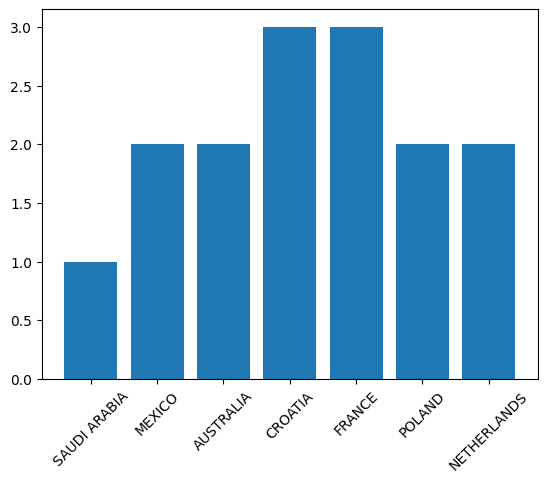

In [19]:
# Graficar los goles hechos por el equipo en cada partido

rival_local = partidos[partidos["1"] == "ARGENTINA"]["2"]
rival_visitante = partidos[partidos["2"] == "ARGENTINA"]["1"]
rivales = pd.concat([rival_local,rival_visitante])
goles_local = partidos[partidos["1"] == "ARGENTINA"]["1_goals"]
goles_visitante = partidos[partidos["2"] == "ARGENTINA"]["2_goals"]
goles = pd.concat([goles_local, goles_visitante])


fig, ax = plt.subplots()
ax.bar(rivales,goles)

plt.xticks(rotation=45)
plt.show()
# Completar

### Tercera Parte

In [20]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar
lgoles = []
lequipos = []

equipos = mundial["1"].unique()
for e in equipos:
  lequipos.append(e)
  lgoles.append(mundial[mundial["1"] == e]["1_goals"].sum() + mundial[mundial["2"] == e]["2_goals"].sum())
  print(e,mundial[mundial["1"] == e]["1_goals"].sum() + mundial[mundial["2"] == e]["2_goals"].sum())


QATAR 1
ENGLAND 13
SENEGAL 5
UNITED STATES 3
ARGENTINA 15
DENMARK 1
MEXICO 2
FRANCE 16
MOROCCO 6
GERMANY 6
SPAIN 9
BELGIUM 1
SWITZERLAND 5
URUGUAY 2
PORTUGAL 12
BRAZIL 8
WALES 1
NETHERLANDS 10
TUNISIA 1
POLAND 3
JAPAN 5
CROATIA 8
CAMEROON 4
KOREA REPUBLIC 5
ECUADOR 4
IRAN 4
AUSTRALIA 4
SAUDI ARABIA 3
CANADA 2
COSTA RICA 3
GHANA 5
SERBIA 5


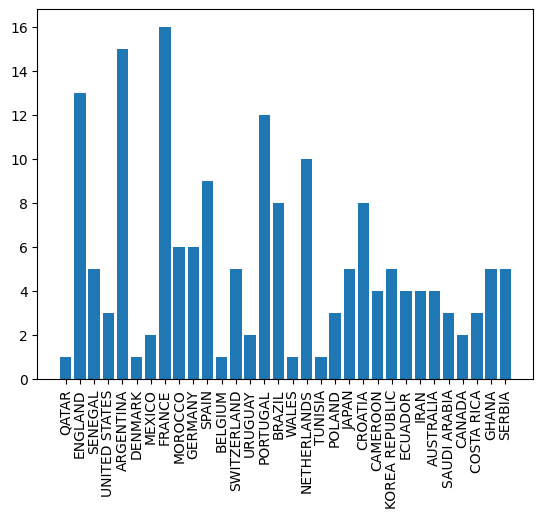

In [21]:
# Graficar los goles por equipo en todo el mundial

fig, ax = plt.subplots()
plt.bar(lequipos,lgoles)
plt.xticks(rotation=90)
plt.show()
# Completar

In [22]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar

golesyequipos = pd.DataFrame({"equipo":lequipos,"goles":lgoles})
golesyequipos.iloc[golesyequipos["goles"].idxmax()]["goles"]

np.int64(16)

In [46]:
# Por cada partido, cual fue la diferencia de goles?
# Completar

print([mundial["1"] + " vs " + mundial["2"], (mundial["1_goals"] - mundial["2_goals"]).abs()])

[0              QATAR vs ECUADOR
1               ENGLAND vs IRAN
2        SENEGAL vs NETHERLANDS
3        UNITED STATES vs WALES
4     ARGENTINA vs SAUDI ARABIA
                ...            
59            ENGLAND vs FRANCE
60         ARGENTINA vs CROATIA
61            FRANCE vs MOROCCO
62           CROATIA vs MOROCCO
63          ARGENTINA vs FRANCE
Length: 64, dtype: object, 0     2
1     4
2     2
3     0
4     1
     ..
59    1
60    3
61    2
62    1
63    0
Length: 64, dtype: int64]


In [48]:
# Por cada partido, cual fue el equipo que gano?
# Completar
for i in range(len(mundial)):
    if mundial["1_goals"][i] > mundial["2_goals"][i]:
        print(mundial["1"][i])
    elif mundial["2_goals"][i] > mundial["1_goals"][i]:
        print(mundial["2"][i])
    elif mundial["1_goals"][i] == mundial["2_goals"][i]:
        print("empataron")


ECUADOR
ENGLAND
NETHERLANDS
empataron
SAUDI ARABIA
empataron
empataron
FRANCE
empataron
JAPAN
SPAIN
BELGIUM
SWITZERLAND
empataron
PORTUGAL
BRAZIL
IRAN
SENEGAL
empataron
empataron
AUSTRALIA
POLAND
FRANCE
ARGENTINA
COSTA RICA
MOROCCO
CROATIA
empataron
empataron
GHANA
BRAZIL
PORTUGAL
NETHERLANDS
SENEGAL
ENGLAND
UNITED STATES
AUSTRALIA
TUNISIA
ARGENTINA
MEXICO
empataron
MOROCCO
JAPAN
GERMANY
URUGUAY
KOREA REPUBLIC
SWITZERLAND
CAMEROON
NETHERLANDS
ARGENTINA
FRANCE
ENGLAND
empataron
BRAZIL
empataron
PORTUGAL
empataron
empataron
MOROCCO
FRANCE
ARGENTINA
FRANCE
CROATIA
empataron


In [72]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar

def filtradorfases(x):
    if x.startswith("Group"):
        x = "Group"
    return x

mundial["group"] = mundial["group"].apply(filtradorfases)
idx1 = mundial.groupby("group")["1_goals"].idxmax()
idx2 = mundial.groupby("group")["2_goals"].idxmax()

print(mundial.loc[idx1, ["group", "1", "1_goals"]],mundial.loc[idx2, ["group", "2", "2_goals"]]
      )

                       group            1  1_goals
63                     Final    ARGENTINA        3
10                     Group        SPAIN        7
62  Play-off for third place      CROATIA        2
57             Quarter-final  NETHERLANDS        2
55               Round of 16     PORTUGAL        6
60                Semi-Final    ARGENTINA        3                        group              2  2_goals
63                     Final         FRANCE        3
43                     Group        GERMANY        4
62  Play-off for third place        MOROCCO        1
57             Quarter-final      ARGENTINA        2
48               Round of 16  UNITED STATES        1
60                Semi-Final        CROATIA        0


### Tercera Parte

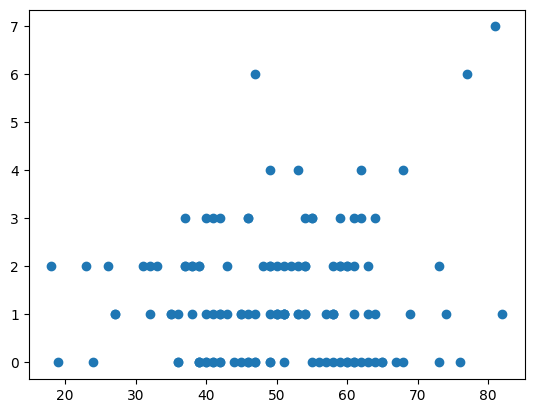

In [55]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar
# grafico que relaciona posesion y goles para ver si estan vinculados
plt.scatter(pd.concat([mundial["1_poss"],mundial["2_poss"]]),pd.concat([mundial["1_goals"],mundial["2_goals"]]))